### **Fusión multimodal profunda**

Este cuaderno se sitúa en un **nivel metodológico más avanzado** dentro del estudio de la clasificación multimodal basada en transformers. Su objetivo no es únicamente presentar una implementación funcional, sino organizar un **mini-protocolo de investigación** alrededor de una idea central de [Kiela et al. (2019)](https://github.com/kapumota/MCC225/blob/main/Semana3/papers/Kiela.pdf): la mejora en clasificación multimodal no depende solo de combinar representaciones al final del modelo, sino de permitir que **imagen y texto interactúen dentro del encoder (codificador)** mediante mecanismos de atención. 

#### **Propósito conceptual**

El foco de este cuaderno está en estudiar, de forma más rigurosa, el paso desde esquemas de **fusión tardía** hacia formas de **fusión profunda** en arquitecturas tipo transformer. En ese sentido, el interés principal recae en cuatro conceptos:

* el enfoque **BERT-first** como eje organizador de la arquitectura,
* la construcción de una **secuencia multimodal conjunta**,
* la **proyección de tokens visuales** al espacio oculto del encoder textual,
* y la interacción entre modalidades mediante **self-attention**.

Este cambio de perspectiva permite analizar la clasificación multimodal ya no como una simple combinación de salidas unimodales, sino como un problema de **integración estructural dentro del modelo**.

#### **Alcance técnico del cuaderno**

La implementación desarrolla una tarea supervisada y manejable de **match/mismatch (correspondencia/no correspondencia)** entre imagen y texto sobre **Flickr8k**, y organiza la comparación entre distintas familias de modelos para evaluar cómo cambia el rendimiento cuando la interacción multimodal ocurre en diferentes niveles de la arquitectura.

En particular, el cuaderno incorpora:

* **`bert-base-uncased` preentrenado** como encoder textual,
* un **encoder visual tipo ViT** en reemplazo de un backbone CNN clásico,
* construcción de **negativos semi-difíciles** con **TF-IDF + vecinos cercanos**,
* comparación entre modelos **text-only**, **image-only**, **fusión tardía** y **MMBT-ViT con fusión profunda**,
* **ablaciones (ablations)** sobre número de tokens visuales y tipo de negativos,
* métricas más completas de evaluación,
* análisis de errores, estratificación por dificultad y discusión crítica de resultados.


#### **Relación conceptual con el paper**

Aunque no reproduce de forma exacta todos los componentes experimentales del artículo, sí conserva sus ideas arquitectónicas más importantes:

* una formulación **BERT-first**,
* la incorporación de **tokens visuales** dentro del encoder textual,
* la diferencia entre **fusión tardía** y **fusión profunda**,
* y la hipótesis de que la interacción multimodal temprana y distribuida puede mejorar la clasificación.

Por tanto, este cuaderno debe entenderse como una **réplica conceptual fuerte**, diseñada para estudiar con mayor profundidad los principios del paper en un formato más adecuado para trabajo avanzado y con un costo computacional razonable.



In [2]:
import os 


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Si estás en Colab o en un entorno limpio, descomenta esta celda.
# %pip install -q -U transformers datasets accelerate scikit-learn matplotlib pandas pillow


In [5]:
import math
import random
import copy
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
)

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoImageProcessor,
    AutoModel,
    BertModel,
    get_linear_schedule_with_warmup,
)

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

def resolve_device(preference: str = "auto") -> torch.device:
    preference = preference.lower().strip()
    if preference == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if preference == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("CUDA no está disponible. Se usará CPU.")
        return torch.device("cpu")
    if preference == "cpu":
        return torch.device("cpu")
    raise ValueError("device_preference debe ser 'auto', 'cpu' o 'cuda'.")


In [38]:
CONFIG = {
    # datos
    "dataset_name": "jxie/flickr8k",
    "profile": "standard",          # quick | standard | research
    "max_images_train": 700,
    "max_images_val": 180,
    "max_images_test": 180,
    "max_text_len": 40,

    # modelos
    "bert_name": "bert-base-uncased",
    "vision_name": "google/vit-base-patch16-224-in21k",
    "visual_grid": (4, 4),          # 16 tokens visuales en MMBT
    "dropout": 0.1,

    # entrenamiento
    "batch_size": 8,
    "epochs": 3,
    "grad_accum_steps": 1,
    "device_preference": "auto",    # auto | cpu | cuda
    "num_workers": None,
    "pin_memory": None,
    "use_amp": True,
    "lr_text": 2e-5,
    "lr_vision": 3e-5,
    "lr_head": 2e-4,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "patience": 2,
    "max_grad_norm": 1.0,

    # ablaciones / ejecución
   "selected_experiments": [
        "TextOnly-BERT",
        "ImageOnly-ViT",
        "Sig-Lip",
        "LateFusion-BERT-ViT",
        "MMBT-ViT-grid-hard",
        "MMBT-ViT-cls-hard",
        "MMBT-ViT-grid-random",
   ],
   # "selected_experiments": [
   #     "Sig-Lip" 
   # ],
    "run_bootstrap_ci": True,
    "bootstrap_rounds": 400,
    "show_attention_example": True,
}

PROFILES = {
    "quick":    {"max_images_train": 300, "max_images_val": 100, "max_images_test": 100, "epochs": 2, "batch_size": 6},
    "standard": {"max_images_train": 700, "max_images_val": 180, "max_images_test": 180, "epochs": 3, "batch_size": 8},
    "research": {"max_images_train": 1200, "max_images_val": 250, "max_images_test": 250, "epochs": 4, "batch_size": 8},
}

if CONFIG["profile"] in PROFILES:
    for k, v in PROFILES[CONFIG["profile"]].items():
        CONFIG[k] = v

DEVICE = resolve_device(CONFIG["device_preference"])
USE_CUDA = DEVICE.type == "cuda"
USE_AMP = bool(CONFIG["use_amp"] and USE_CUDA)

if CONFIG["num_workers"] is None:
    CONFIG["num_workers"] = 2 if USE_CUDA else 0

if CONFIG["pin_memory"] is None:
    CONFIG["pin_memory"] = USE_CUDA

runtime_info = {
    "device": str(DEVICE),
    "cuda_available": torch.cuda.is_available(),
    "amp_enabled": USE_AMP,
    "num_workers": CONFIG["num_workers"],
    "pin_memory": CONFIG["pin_memory"],
}
if USE_CUDA:
    runtime_info["gpu_name"] = torch.cuda.get_device_name(0)

print(runtime_info)
CONFIG


{'device': 'cuda', 'cuda_available': True, 'amp_enabled': True, 'num_workers': 2, 'pin_memory': True, 'gpu_name': 'NVIDIA GeForce RTX 3060'}


{'dataset_name': 'jxie/flickr8k',
 'profile': 'standard',
 'max_images_train': 700,
 'max_images_val': 180,
 'max_images_test': 180,
 'max_text_len': 40,
 'bert_name': 'bert-base-uncased',
 'vision_name': 'google/vit-base-patch16-224-in21k',
 'visual_grid': (4, 4),
 'dropout': 0.1,
 'batch_size': 8,
 'epochs': 3,
 'grad_accum_steps': 1,
 'device_preference': 'auto',
 'num_workers': 2,
 'pin_memory': True,
 'use_amp': True,
 'lr_text': 2e-05,
 'lr_vision': 3e-05,
 'lr_head': 0.0002,
 'weight_decay': 0.01,
 'warmup_ratio': 0.1,
 'patience': 2,
 'max_grad_norm': 1.0,
 'selected_experiments': ['TextOnly-BERT',
  'ImageOnly-ViT',
  'Sig-Lip',
  'LateFusion-BERT-ViT',
  'MMBT-ViT-grid-hard',
  'MMBT-ViT-cls-hard',
  'MMBT-ViT-grid-random'],
 'run_bootstrap_ci': True,
 'bootstrap_rounds': 400,
 'show_attention_example': True}


#### **1. Construcción de una tarea multimodal supervisada a partir de datos reales**

En esta sección se construye una tarea de **clasificación multimodal supervisada** a partir de **Flickr8k**, un dataset suficientemente realista para un análisis serio, pero lo bastante manejable para mantener un costo computacional razonable en un cuaderno docente de nivel avanzado.

El problema no se formula como **image captioning (generación de descripciones de imágenes)** ni como una **recuperación multimodal completa**. En su lugar, se define una tarea binaria de **alineamiento imagen-texto**, donde el objetivo es determinar si ambos elementos corresponden semánticamente entre sí:

* **1 = match**: la imagen y el caption son compatibles
* **0 = mismatch**: la imagen y el caption no corresponden

Esta formulación permite estudiar de manera más controlada la integración entre modalidades y comparar con claridad distintas familias de modelos, incluyendo:

* **baselines unimodales**,
* esquemas de **fusión tardía**,
* y arquitecturas de **fusión profunda estilo MMBT**.

Desde el punto de vista metodológico, esta decisión es importante porque transforma el dataset en un entorno adecuado para analizar una pregunta central de la clasificación multimodal: **cuánto mejora el rendimiento cuando imagen y texto interactúan dentro del modelo, y no solo al final**.

Además, se construyen dos variantes del problema para introducir distintos niveles de dificultad experimental:

* **hard**: usando **negativos semi-difíciles**, es decir, captions incorrectos pero semánticamente cercanos,
* **random**: usando **negativos aleatorios**, que generan contrastes más fáciles.

Esta doble configuración permite separar mejor dos factores que suelen confundirse en evaluación multimodal: por un lado, la capacidad real del modelo para integrar modalidades y por otro, la dificultad intrínseca de los pares construidos.



In [7]:
raw = load_dataset(CONFIG["dataset_name"])
raw


DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})

In [8]:
### se recupera varios captions para el dataset 
def build_caption_table(hf_split, max_images: Optional[int], seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    indices = np.arange(len(hf_split))
    if max_images is not None and max_images < len(indices):
        indices = rng.choice(indices, size=max_images, replace=False)
        indices = np.sort(indices)

    rows = []
    for idx in tqdm(indices, desc="Exploding captions"):
        ex = hf_split[int(idx)]
        for j in range(5):
            key = f"caption_{j}"
            txt = ex.get(key, None)
            if txt is not None and str(txt).strip():
                rows.append({
                    "hf_index": int(idx),
                    "image_id": int(idx),
                    "caption": str(txt).strip(),
                    "caption_len": len(str(txt).strip().split()),
                })
    return pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

train_meta = build_caption_table(raw["train"], CONFIG["max_images_train"], seed=SEED)
val_meta   = build_caption_table(raw["validation"], CONFIG["max_images_val"], seed=SEED + 1)
test_meta  = build_caption_table(raw["test"], CONFIG["max_images_test"], seed=SEED + 2)

print("train_meta:", train_meta.shape)
print("val_meta:  ", val_meta.shape)
print("test_meta: ", test_meta.shape)
train_meta.head()


Exploding captions: 100%|██████████| 250/250 [00:00<00:00, 782.45it/s]

train_meta: (5997, 4)
val_meta:   (1250, 4)
test_meta:  (1250, 4)


,hf_index,image_id,caption,caption_len
0,24,24,A brown dog wades through water and walks towa...,12
1,24,24,A dog has waded through shallow water to reach...,13
2,24,24,A light brown dog is splashing in the water wi...,13
3,24,24,A small brown dog is about ready to exit the w...,15
4,24,24,A yellow dog in shallow water .,7


In [9]:
def mine_negative_matches(
    meta_df: pd.DataFrame,
    seed: int = 42,
    topk: int = 15,
    max_features: int = 12000,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Devuelve dos datasets:
    - hard_pairs: positivos + negativos semi-difíciles
    - random_pairs: positivos + negativos aleatorios
    """
    rng = random.Random(seed)
    df = meta_df.copy().reset_index(drop=True)

    pos = df.copy()
    pos["label"] = 1
    pos["source"] = "positive"
    pos["neg_similarity"] = np.nan
    pos["difficulty"] = "positive"

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=max_features,
        ngram_range=(1, 2),
        min_df=1,
    )
    X = vectorizer.fit_transform(df["caption"].tolist())

    nn_model = NearestNeighbors(
        n_neighbors=min(topk + 25, len(df)),
        metric="cosine",
        algorithm="brute",
    )
    nn_model.fit(X)
    dists, neighs = nn_model.kneighbors(X)

    hard_rows = []
    random_rows = []
    image_ids = df["image_id"].tolist()
    all_by_other_image = {
        i: [j for j in range(len(df)) if image_ids[j] != image_ids[i]]
        for i in range(len(df))
    }

    sim_values = []

    for i, (dist_row, nbr_row) in enumerate(tqdm(zip(dists, neighs), total=len(df), desc="Mining negatives")):
        hard_candidates = [
            (j, 1.0 - float(dist))
            for j, dist in zip(nbr_row[1:], dist_row[1:])
            if image_ids[j] != image_ids[i]
        ]

        if not hard_candidates:
            j = rng.choice(all_by_other_image[i])
            hard_sim = 0.0
        else:
            shortlist = hard_candidates[:min(topk, len(hard_candidates))]
            j, hard_sim = rng.choice(shortlist)

        sim_values.append(hard_sim)

        hard_rows.append({
            "hf_index": int(df.loc[i, "hf_index"]),
            "image_id": int(df.loc[i, "image_id"]),
            "caption": str(df.loc[j, "caption"]),
            "caption_len": int(df.loc[j, "caption_len"]),
            "label": 0,
            "source": "hard_negative",
            "neg_similarity": hard_sim,
            "neg_caption_from_image_id": int(df.loc[j, "image_id"]),
        })

        j_rand = rng.choice(all_by_other_image[i])
        random_rows.append({
            "hf_index": int(df.loc[i, "hf_index"]),
            "image_id": int(df.loc[i, "image_id"]),
            "caption": str(df.loc[j_rand, "caption"]),
            "caption_len": int(df.loc[j_rand, "caption_len"]),
            "label": 0,
            "source": "random_negative",
            "neg_similarity": np.nan,
            "neg_caption_from_image_id": int(df.loc[j_rand, "image_id"]),
        })

    hard_neg = pd.DataFrame(hard_rows)
    random_neg = pd.DataFrame(random_rows)

    if len(sim_values) > 0:
        q1, q2 = np.quantile(sim_values, [0.33, 0.66])
        def bin_difficulty(x):
            if x <= q1:
                return "easy"
            elif x <= q2:
                return "medium"
            return "hard"
        hard_neg["difficulty"] = hard_neg["neg_similarity"].apply(bin_difficulty)
    else:
        hard_neg["difficulty"] = "hard"

    random_neg["difficulty"] = "random"

    hard_pairs = pd.concat([pos, hard_neg], ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    random_pairs = pd.concat([pos, random_neg], ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return hard_pairs, random_pairs

train_pairs_hard, train_pairs_random = mine_negative_matches(train_meta, seed=SEED, topk=15)
val_pairs_hard,   val_pairs_random   = mine_negative_matches(val_meta, seed=SEED + 1, topk=10)
test_pairs_hard,  test_pairs_random  = mine_negative_matches(test_meta, seed=SEED + 2, topk=10)

print("train hard:", train_pairs_hard.shape, train_pairs_hard["label"].value_counts().to_dict())
print("train rand:", train_pairs_random.shape, train_pairs_random["label"].value_counts().to_dict())
train_pairs_hard.head()


Mining negatives: 100%|██████████| 1250/1250 [00:00<00:00, 8272.04it/s]

train hard: (11994, 9) {0: 5997, 1: 5997}
train rand: (11994, 9) {0: 5997, 1: 5997}


,hf_index,image_id,caption,caption_len,label,source,neg_similarity,difficulty,neg_caption_from_image_id
0,4416,4416,A new bride dressed in white throws a bouquet ...,15,0,hard_negative,0.160815,easy,3392.0
1,1401,1401,A dog is jumping down the stairs .,8,1,positive,NaN,positive,NaN
2,1735,1735,Three horses and their jockeys compete in a ra...,10,1,positive,NaN,positive,NaN
3,1543,1543,Two people raise up their arms in a rollercoas...,10,0,hard_negative,0.260701,medium,2080.0
4,419,419,A grey bearded man is sleeping under a tree .,10,1,positive,NaN,positive,NaN


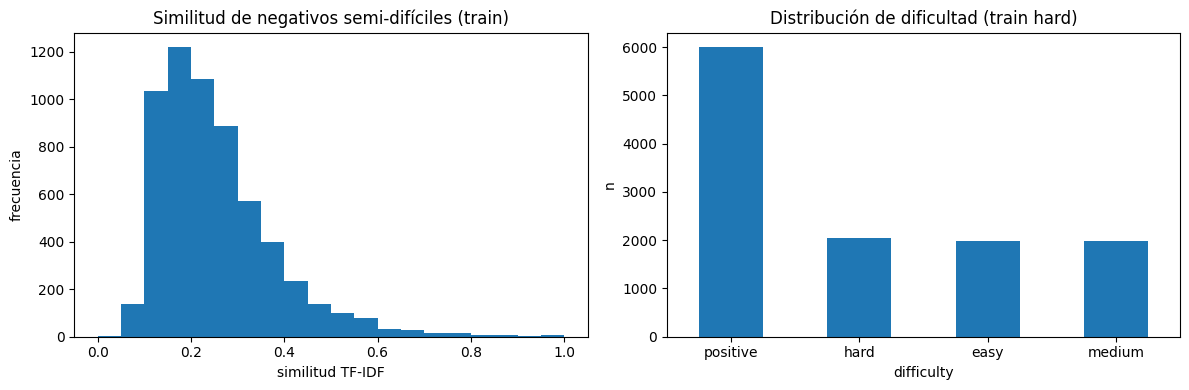

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hard_sim = train_pairs_hard.loc[train_pairs_hard["label"] == 0, "neg_similarity"].dropna()
axes[0].hist(hard_sim, bins=20)
axes[0].set_title("Similitud de negativos semi-difíciles (train)")
axes[0].set_xlabel("similitud TF-IDF")
axes[0].set_ylabel("frecuencia")

train_pairs_hard["difficulty"].value_counts().plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Distribución de dificultad (train hard)")
axes[1].set_xlabel("difficulty")
axes[1].set_ylabel("n")

plt.tight_layout()
plt.show()


#### **2. Tokenización, procesamiento visual y construcción del `DataLoader`**

En esta sección se organiza el flujo de entrada multimodal que alimentará a los modelos. Para el componente textual, se utiliza la **tokenización de BERT**, mientras que para el componente visual se emplea un **encoder tipo ViT**, en lugar de una CNN seguida de una compresión a un único vector global.

Esta decisión es metodológicamente importante porque permite estudiar con mayor precisión cómo se representa la imagen dentro de una arquitectura multimodal basada en transformers. En particular, el cuaderno incorpora una **ablación** sobre la forma de construir la entrada visual, comparando dos variantes:

* **`cls_only`**: la imagen se representa mediante un único token visual resumido,
* **`patch_grid`**: la imagen se representa mediante varios tokens visuales agregados en forma de rejilla.

La comparación entre ambas configuraciones permite discutir una pregunta central en el estudio de la fusión multimodal profunda: **qué se gana cuando la imagen no entra al modelo como un solo resumen global, sino como una estructura compuesta por múltiples tokens visuales**.

Desde el punto de vista conceptual, esta diferencia es clave. La variante **`cls_only`** aproxima una representación visual más compacta y cercana a los esquemas de resumen global, mientras que **`patch_grid`** preserva una estructura espacial más variada y ofrece al encoder mayores posibilidades de interacción entre regiones visuales y tokens textuales a través de **self-attention**. Por ello, esta **ablación** resulta especialmente útil para analizar una de las intuiciones más importantes detrás de MMBT y de los modelos multimodales tipo transformer: la fusión puede volverse más expresiva cuando la imagen participa como una **secuencia de tokens**, y no solo como una única representación agregada.

Finalmente, el `DataLoader` se encarga de ensamblar de forma consistente estas entradas multimodales, asegurando la correcta alineación entre:

* la secuencia tokenizada de texto,
* la representación visual procesada,
* y la etiqueta binaria de clasificación `match / mismatch`.

De este modo, el pipeline de datos no solo prepara tensores para entrenamiento, sino que define explícitamente la forma en que el modelo recibirá y articulará la información de ambas modalidades.



In [11]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["bert_name"], use_fast=True)
image_processor = AutoImageProcessor.from_pretrained(CONFIG["vision_name"])

class FlickrPairDataset(Dataset):
    def __init__(self, hf_split, pair_df: pd.DataFrame):
        self.hf_split = hf_split
        self.df = pair_df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        ex = self.hf_split[int(row.hf_index)]
        image = ex["image"]
        if not isinstance(image, Image.Image):
            image = Image.fromarray(np.asarray(image))
        return {
            "image": image.convert("RGB"),
            "caption": str(row.caption),
            "label": int(row.label),
            "hf_index": int(row.hf_index),
            "image_id": int(row.image_id),
            "source": str(row.source),
            "difficulty": str(row.difficulty),
            "caption_len": int(row.caption_len),
            "neg_similarity": None if pd.isna(row.neg_similarity) else float(row.neg_similarity),
        }

def make_collate_fn(tokenizer, image_processor, max_text_len: int):
    def collate_fn(batch):
        captions = [x["caption"] for x in batch]
        enc = tokenizer(
            captions,
            padding=True,
            truncation=True,
            max_length=max_text_len,
            return_tensors="pt",
        )

        images = [x["image"] for x in batch]
        img_enc = image_processor(images=images, return_tensors="pt")

        labels = torch.tensor([x["label"] for x in batch], dtype=torch.long)
        meta = pd.DataFrame({
            "hf_index": [x["hf_index"] for x in batch],
            "image_id": [x["image_id"] for x in batch],
            "caption": captions,
            "source": [x["source"] for x in batch],
            "difficulty": [x["difficulty"] for x in batch],
            "caption_len": [x["caption_len"] for x in batch],
            "neg_similarity": [x["neg_similarity"] for x in batch],
        })

        return {
            "input_ids": enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "pixel_values": img_enc["pixel_values"],
            "labels": labels,
            "meta": meta,
        }
    return collate_fn

collate_fn = make_collate_fn(tokenizer, image_processor, CONFIG["max_text_len"])

pair_tables = {
    "hard": {
        "train": train_pairs_hard,
        "val": val_pairs_hard,
        "test": test_pairs_hard,
    },
    "random": {
        "train": train_pairs_random,
        "val": val_pairs_random,
        "test": test_pairs_random,
    },
}

def make_loaders(variant: str = "hard") -> Tuple[Dataset, Dataset, Dataset, DataLoader, DataLoader, DataLoader]:
    train_ds = FlickrPairDataset(raw["train"], pair_tables[variant]["train"])
    val_ds   = FlickrPairDataset(raw["validation"], pair_tables[variant]["val"])
    test_ds  = FlickrPairDataset(raw["test"], pair_tables[variant]["test"])

    train_loader = DataLoader(
        train_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"],
        pin_memory=CONFIG["pin_memory"],
        collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=CONFIG["pin_memory"],
        collate_fn=collate_fn,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=CONFIG["pin_memory"],
        collate_fn=collate_fn,
    )
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

train_ds_hard, val_ds_hard, test_ds_hard, train_loader_hard, val_loader_hard, test_loader_hard = make_loaders("hard")
_, _, _, train_loader_random, val_loader_random, test_loader_random = make_loaders("random")

batch = next(iter(train_loader_hard))
{k: (v.shape if torch.is_tensor(v) else type(v)) for k, v in batch.items() if k != "meta"}


{'input_ids': torch.Size([8, 19]),
 'attention_mask': torch.Size([8, 19]),
 'pixel_values': torch.Size([8, 3, 224, 224]),
 'labels': torch.Size([8])}

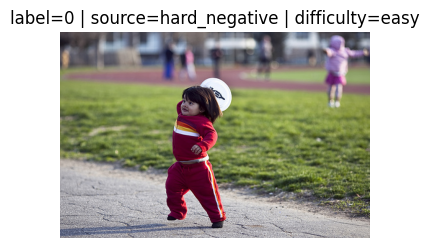

A new bride dressed in white throws a bouquet to waiting females behind her .


In [12]:
# Inspección rápida de un ejemplo
sample = train_ds_hard[0]
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(sample["image"])
ax.axis("off")
ax.set_title(f'label={sample["label"]} | source={sample["source"]} | difficulty={sample["difficulty"]}')
plt.show()

print(sample["caption"])


#### **3. Familias de modelos para clasificación multimodal**

En esta sección se definen cuatro familias de modelos, organizadas para comparar distintos niveles de integración entre modalidades y analizar cómo cambia el rendimiento cuando la interacción entre imagen y texto ocurre en diferentes puntos de la arquitectura.

Las familias consideradas son las siguientes:

1. **TextOnly-BERT**
2. **ImageOnly-ViT**
3. **LateFusion-BERT-ViT**
4. **MMBT-ViT**, con dos variantes:

   * `patch_grid`
   * `cls_only`

Esta organización permite recorrer un continuo metodológico que va desde modelos **unimodales**, pasa por una estrategia de **fusión tardía**, y culmina en una arquitectura de **fusión profunda** inspirada en MMBT.

Los modelos **TextOnly-BERT** e **ImageOnly-ViT** funcionan como baselines unimodales. Su papel es establecer cuánto puede resolver cada modalidad por separado y ofrecer un punto de referencia para interpretar si la mejora de los modelos multimodales proviene realmente de la integración de información, y no solo del predominio de una de las dos entradas.

El modelo **LateFusion-BERT-ViT** representa una estrategia multimodal clásica: texto e imagen se codifican de forma independiente y sus representaciones se combinan únicamente en la etapa final de clasificación. Esta arquitectura resulta útil como baseline fuerte, porque permite medir el efecto de añadir ambas modalidades sin modificar todavía la estructura interna del encoder.

Finalmente, **MMBT-ViT** constituye la familia más relevante desde el punto de vista conceptual. En este caso, la imagen no se incorpora solo como una representación global, sino como una entrada que puede integrarse dentro del encoder textual mediante una secuencia multimodal compartida. Esto permite que la interacción entre modalidades ocurra por **self-attention**, en lugar de quedar restringida a una combinación tardía de embeddings finales.

Dentro de esta familia, la variante **`patch_grid`** es la más interesante conceptualmente, porque aproxima de manera más fiel la idea de que la imagen entre al encoder como **múltiples tokens visuales**. En contraste, la variante **`cls_only`** resume la información visual en un solo token, lo que ofrece una comparación útil para analizar cuánto aporta una representación visual más estructurada. 

Esta distinción conecta directamente con una de las preguntas centrales del cuaderno: si la clasificación multimodal mejora cuando la imagen participa como una **secuencia de tokens** y no solo como un resumen compacto.



In [32]:
class TextOnlyBERTClassifier(nn.Module):
    def __init__(self, bert_name: str, num_labels: int = 2, dropout: float = 0.1):
        super().__init__()
        self.text_encoder = BertModel.from_pretrained(bert_name)
        hidden = self.text_encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, num_labels),
        )

    def forward(self, input_ids, attention_mask, labels=None, **kwargs):
        out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        cls = out.last_hidden_state[:, 0]
        logits = self.classifier(cls)
        loss = F.cross_entropy(logits, labels) if labels is not None else None
        return {"loss": loss, "logits": logits}


class ImageOnlyViTClassifier(nn.Module):
    def __init__(self, vision_name: str, num_labels: int = 2, dropout: float = 0.1):
        super().__init__()
        self.vision_encoder = AutoModel.from_pretrained(vision_name)
        vision_dim = self.vision_encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(vision_dim, num_labels),
        )

    def forward(self, pixel_values, labels=None, **kwargs):
        out = self.vision_encoder(pixel_values=pixel_values, return_dict=True)
        cls = out.last_hidden_state[:, 0]
        logits = self.classifier(cls)
        loss = F.cross_entropy(logits, labels) if labels is not None else None
        return {"loss": loss, "logits": logits}

class SigLipV1(nn.Module):
    def __init__(
        self,
        bert_name: str,
        vision_name: str,
        projection_dim: int = 256,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.text_encoder = BertModel.from_pretrained(bert_name)
        self.vision_encoder = AutoModel.from_pretrained(vision_name)

        hidden_t = self.text_encoder.config.hidden_size
        hidden_v = self.vision_encoder.config.hidden_size

        # Proyecciones al mismo espacio
        self.text_proj = nn.Sequential(
            nn.Linear(hidden_t, projection_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.vision_proj = nn.Sequential(
            nn.Linear(hidden_v, projection_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # temperatura aprendible (como CLIP/SigLIP)
        self.logit_scale = nn.Parameter(torch.ones([]) * torch.log(torch.tensor(1 / 0.07)))
        self.b = nn.Parameter(torch.tensor(-10.0)) ### segun paper 

    def forward(
        self,
        input_ids,
        attention_mask,
        pixel_values,
        labels=None,
        **kwargs
    ):

        # ----- TEXT -----
        t_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )

        # [B, seq_len, hidden]
        text_cls = t_out.last_hidden_state[:, 0] # token cls, 
        #mean pooling

        # ----- IMAGE -----
        v_out = self.vision_encoder(
            pixel_values=pixel_values,
            return_dict=True,
        )

        # [B, num_patches+1, hidden]
        vision_cls = v_out.last_hidden_state[:, 0] # token cls 

        # ----- PROJECTION -----
        text_embeds = self.text_proj(text_cls)
        image_embeds = self.vision_proj(vision_cls)

        # normalización L2
        text_embeds = F.normalize(text_embeds, dim=-1) #(B, n_dmin emb)
        image_embeds = F.normalize(image_embeds, dim=-1 #( B, embd)

        # similitud
        logit_scale = self.logit_scale.exp() # T

        logits = logit_scale * image_embeds @ text_embeds.T + self.b
        # shape: [B, B]

        loss = None

        if labels is not None:

            # matriz objetivo
            # positivos en diagonal
            # negativos fuera
            targets = torch.eye(
                logits.size(0),
                device=logits.device
            )

            # convertir {0,1} -> {-1,+1}
            z = targets * 2 - 1

            # SigLIP sigmoid loss
            loss = torch.log(
                1 + torch.exp(-z * logits)
            ).mean()

        return {
            "loss": loss,
            "logits": logits 
        }

        
class LateFusionBertViTClassifier(nn.Module):
    def __init__(self, bert_name: str, vision_name: str, num_labels: int = 2, dropout: float = 0.1):
        super().__init__()
        self.text_encoder = BertModel.from_pretrained(bert_name)
        self.vision_encoder = AutoModel.from_pretrained(vision_name)

        hidden_t = self.text_encoder.config.hidden_size
        hidden_v = self.vision_encoder.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(hidden_t + hidden_v, hidden_t),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_t, num_labels),
        )

    def forward(self, input_ids, attention_mask, pixel_values, labels=None, **kwargs):
        t_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        v_out = self.vision_encoder(
            pixel_values=pixel_values,
            return_dict=True,
        )
        text_cls = t_out.last_hidden_state[:, 0]
        vision_cls = v_out.last_hidden_state[:, 0]
        fused = torch.cat([text_cls, vision_cls], dim=-1)
        logits = self.classifier(fused)
        loss = F.cross_entropy(logits, labels) if labels is not None else None
        return {"loss": loss, "logits": logits}


class MMBTViTClassifier(nn.Module):
    def __init__(
        self,
        bert_name: str,
        vision_name: str,
        visual_grid: Tuple[int, int] = (4, 4),
        visual_strategy: str = "patch_grid",   # patch_grid | cls_only
        num_labels: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.text_encoder = BertModel.from_pretrained(bert_name)
        self.vision_encoder = AutoModel.from_pretrained(vision_name)
        self.visual_strategy = visual_strategy
        self.visual_grid = visual_grid

        text_hidden = self.text_encoder.config.hidden_size
        vision_hidden = self.vision_encoder.config.hidden_size

        self.visual_projection = nn.Linear(vision_hidden, text_hidden)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(text_hidden, num_labels)

    def _select_visual_tokens(self, vision_seq: torch.Tensor) -> torch.Tensor:
        # vision_seq: [B, 1 + num_patches, H]
        if self.visual_strategy == "cls_only":
            return vision_seq[:, :1, :]  # un solo token visual

        patch_tokens = vision_seq[:, 1:, :]
        bsz, n_patches, hidden = patch_tokens.shape
        grid_size = int(math.sqrt(n_patches))
        if grid_size * grid_size != n_patches:
            raise ValueError(f"No se puede rearmar una rejilla cuadrada con {n_patches} patches.")

        patch_map = patch_tokens.transpose(1, 2).reshape(bsz, hidden, grid_size, grid_size)
        pooled = F.adaptive_avg_pool2d(patch_map, self.visual_grid)
        visual_tokens = pooled.flatten(2).transpose(1, 2)
        return visual_tokens

    def forward(self, input_ids, attention_mask, pixel_values, labels=None, output_attentions=False, **kwargs):
        # 1. Tokens visuales
        v_out = self.vision_encoder(
            pixel_values=pixel_values,
            output_attentions=False,
            return_dict=True,
        )
        visual_tokens = self._select_visual_tokens(v_out.last_hidden_state)
        visual_tokens = self.visual_projection(visual_tokens)

        # 2.Embeddings textuales base (sin pasar todavía por todo BERT)
        emb = self.text_encoder.embeddings
        text_word = emb.word_embeddings(input_ids)

        batch_size, text_len, hidden = text_word.shape
        num_visual = visual_tokens.size(1)
        device = text_word.device

        # posición reiniciada por segmento, siguiendo la intuición del paper
        text_pos_ids = torch.arange(text_len, device=device).unsqueeze(0).expand(batch_size, -1)
        vis_pos_ids  = torch.arange(num_visual, device=device).unsqueeze(0).expand(batch_size, -1)

        text_seg_ids = torch.zeros((batch_size, text_len), dtype=torch.long, device=device)
        vis_seg_ids  = torch.ones((batch_size, num_visual), dtype=torch.long, device=device)

        text_emb = (
            text_word
            + emb.position_embeddings(text_pos_ids)
            + emb.token_type_embeddings(text_seg_ids)
        )
        vis_emb = (
            visual_tokens
            + emb.position_embeddings(vis_pos_ids)
            + emb.token_type_embeddings(vis_seg_ids)
        )

        fused_emb = torch.cat([text_emb, vis_emb], dim=1)
        fused_emb = emb.LayerNorm(fused_emb)
        fused_emb = emb.dropout(fused_emb)

        fused_mask = torch.cat(
            [attention_mask, torch.ones((batch_size, num_visual), dtype=attention_mask.dtype, device=device)],
            dim=1,
        )

        extended_mask = self.text_encoder.get_extended_attention_mask(
            fused_mask,
            fused_mask.shape,
            device,
        )

        encoder_outputs = self.text_encoder.encoder(
            fused_emb,
            attention_mask=extended_mask,
            output_attentions=output_attentions,
            return_dict=True,
        )

        seq_out = encoder_outputs.last_hidden_state
        pooled = self.text_encoder.pooler(seq_out) if self.text_encoder.pooler is not None else seq_out[:, 0]
        logits = self.classifier(self.dropout(pooled))
        loss = F.cross_entropy(logits, labels) if labels is not None else None

        out = {"loss": loss, "logits": logits}
        if output_attentions:
            out["attentions"] = encoder_outputs.attentions
            out["num_visual_tokens"] = num_visual
        return out


## 4. Métricas, entrenamiento y protocolo de evaluación

En esta sección se define el protocolo de entrenamiento y evaluación utilizado para comparar los distintos modelos multimodales del cuaderno. El objetivo no es únicamente entrenar modelos y reportar una métrica final, sino también analizar su comportamiento de manera más completa y consistente.

Para ello, se incorporan varios elementos comunes en experimentos de aprendizaje profundo:

* **Early stopping**, para reducir el sobreajuste y conservar el modelo con mejor capacidad de generalización.
* **Tasas de aprendizaje discriminativas**, permitiendo ajustar diferentes partes de la arquitectura con distintas velocidades de aprendizaje.
* **Múltiples métricas de evaluación**, con el fin de analizar el rendimiento desde varias perspectivas y no depender únicamente de la accuracy.
* **Intervalos bootstrap**, utilizados para estimar la variabilidad de las métricas obtenidas.
* **Almacenamiento de metadatos**, que facilita posteriores análisis de errores, ejemplos difíciles y comportamiento por subconjuntos de datos.

Esta sección también enfatiza una idea importante en clasificación multimodal: una única métrica agregada no siempre es suficiente para comparar arquitecturas distintas. Al evaluar modelos unimodales, esquemas de fusión tardía y métodos de fusión profunda, resulta útil conservar información adicional que permita interpretar mejor el comportamiento de cada modelo sobre ejemplos individuales.

Por ello, el entrenamiento y la evaluación se consideran aquí parte del diseño experimental del cuaderno, y no solamente una etapa operativa del pipeline.


In [37]:
from transformers import get_cosine_schedule_with_warmup ### agregamos warmup

def parameter_groups_with_weight_decay(named_params, lr: float, weight_decay: float):
    no_decay = ["bias", "LayerNorm.weight", "layer_norm.weight"]
    decay_params, no_decay_params = [], []

    for name, param in named_params:
        if not param.requires_grad:
            continue
        if any(nd in name for nd in no_decay):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    groups = []
    if decay_params:
        groups.append({"params": decay_params, "lr": lr, "weight_decay": weight_decay})
    if no_decay_params:
        groups.append({"params": no_decay_params, "lr": lr, "weight_decay": 0.0})
    return groups

def make_optimizer_and_scheduler(model: nn.Module, train_loader_len: int, epochs: int):
    named_params = list(model.named_parameters())

    text_named = [(n, p) for n, p in named_params if n.startswith("text_encoder.")]
    vision_named = [(n, p) for n, p in named_params if n.startswith("vision_encoder.")]
    head_named = [(n, p) for n, p in named_params if not (n.startswith("text_encoder.") or n.startswith("vision_encoder."))]

    groups = []
    if text_named:
        groups += parameter_groups_with_weight_decay(text_named, CONFIG["lr_text"], CONFIG["weight_decay"])
    if vision_named:
        groups += parameter_groups_with_weight_decay(vision_named, CONFIG["lr_vision"], CONFIG["weight_decay"])
    if head_named:
        groups += parameter_groups_with_weight_decay(head_named, CONFIG["lr_head"], CONFIG["weight_decay"])

    optimizer = torch.optim.AdamW(groups)
    total_steps = math.ceil(train_loader_len / CONFIG["grad_accum_steps"]) * epochs
    warmup_steps = int(total_steps * CONFIG["warmup_ratio"])

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    return optimizer, scheduler

def compute_binary_metrics(y_true, y_prob, threshold: float = 0.5) -> Dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    out = {
        "acc": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

    try:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        out["roc_auc"] = np.nan

    try:
        out["avg_precision"] = average_precision_score(y_true, y_prob)
    except Exception:
        out["avg_precision"] = np.nan

    return out

def bootstrap_ci(y_true, y_prob, metric: str = "f1", rounds: int = 400, seed: int = 42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    stats = []

    for _ in range(rounds):
        idx = rng.integers(0, n, size=n)
        sample_metrics = compute_binary_metrics(y_true[idx], y_prob[idx])
        stats.append(sample_metrics[metric])

    lo, hi = np.quantile(stats, [0.025, 0.975])
    return float(lo), float(hi)

@torch.no_grad()
def evaluate(model, loader, device=None):
    device = DEVICE if device is None else torch.device(device)
    model.eval()

    losses = []
    probs, preds, golds = [], [], []
    meta_frames = []

    for batch in tqdm(loader, desc="Eval", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        out = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            labels=labels,
        )

        if out["loss"] is not None:
            losses.append(out["loss"].item())

        prob = out["logits"].softmax(dim=-1)[:, 1]
        pred = (prob >= 0.5).long()

        probs.extend(prob.cpu().numpy().tolist())
        preds.extend(pred.cpu().numpy().tolist())
        golds.extend(labels.cpu().numpy().tolist())

        meta = batch["meta"].copy()
        meta["gold"] = labels.cpu().numpy()
        meta["pred"] = pred.cpu().numpy()
        meta["prob_match"] = prob.cpu().numpy()
        meta_frames.append(meta)

    metrics = compute_binary_metrics(golds, probs)
    metrics["loss"] = float(np.mean(losses)) if losses else np.nan

    eval_df = pd.concat(meta_frames, ignore_index=True)
    return metrics, np.asarray(golds), np.asarray(preds), np.asarray(probs), eval_df

def train_model(model, train_loader, val_loader, epochs: int, device=None):

    steps_per_epoch = math.ceil(
        len(train_loader) / CONFIG["grad_accum_steps"]
    )
    
    total_training_steps = (
        steps_per_epoch * CONFIG["epochs"]
    )
    #### steps 
    warmup_steps = int(
    total_training_steps * 0.1
)
    
 
    
    device = DEVICE if device is None else torch.device(device)
    optimizer, scheduler = make_optimizer_and_scheduler(model, len(train_loader), epochs)
    scaler = torch.amp.GradScaler(device.type, enabled=USE_AMP)

    history = []
    best_state = None
    best_f1 = -1.0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        optimizer.zero_grad(set_to_none=True)

        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Train epoch {epoch}")
        for step, batch in pbar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            with torch.autocast(device_type=device.type, enabled=USE_AMP):
                out = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    pixel_values=pixel_values,
                    labels=labels,
                )
                loss = out["loss"] / CONFIG["grad_accum_steps"]

            scaler.scale(loss).backward()

            if ((step + 1) % CONFIG["grad_accum_steps"] == 0) or ((step + 1) == len(train_loader)):
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            losses.append(loss.item() * CONFIG["grad_accum_steps"])
            pbar.set_postfix(train_loss=float(np.mean(losses[-20:])))

        val_metrics, _, _, _, _ = evaluate(model, val_loader, device=device)
        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["roc_auc"],
        }
        history.append(row)
        print(row)

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= CONFIG["patience"]:
            print(f"Early stopping en época {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


#### **5. Matriz experimental y lógica de comparación**

Esta versión del cuaderno incorpora una **pequeña matriz experimental** diseñada para comparar de manera sistemática distintas hipótesis sobre integración multimodal. Más que una colección de corridas aisladas, esta matriz debe leerse como una estructura de contraste entre modelos, representaciones visuales y niveles de dificultad del problema.

La interpretación metodológica de los experimentos es la siguiente:

* **TextOnly** e **ImageOnly** funcionan como **controles unimodales**. Su propósito es establecer cuánto puede resolverse con cada modalidad por separado y servir como referencia para juzgar si la ganancia de los modelos multimodales proviene realmente de la combinación de información.
* **LateFusion** constituye el **baseline fuerte clásico**. Permite medir cuánto se obtiene al combinar ambas modalidades sin introducir todavía una integración profunda dentro del encoder.
* **MMBT-ViT-grid-hard** representa la **hipótesis principal** del cuaderno. En esta configuración, la imagen entra como varios tokens visuales y la tarea se evalúa en una condición más exigente, con negativos semi-difíciles. Es, por tanto, la variante que mejor pone a prueba la idea de que la clasificación multimodal mejora cuando la interacción entre modalidades ocurre dentro del modelo.
* **MMBT-ViT-cls-hard** funciona como una **ablación estructural**, centrada en comparar una representación visual reducida a un solo token frente a una representación compuesta por múltiples tokens visuales. Esta comparación permite examinar cuánto aporta mantener una estructura visual más rica dentro del encoder.
* **MMBT-ViT-grid-random** introduce una **ablación sobre la dificultad del dataset**. Al reemplazar negativos semi-difíciles por negativos aleatorios, esta variante ayuda a distinguir cuánto del rendimiento observado depende de la arquitectura y cuánto se explica por una tarea más o menos desafiante.

En conjunto, esta matriz experimental permite analizar tres ejes centrales del cuaderno:

* el contraste entre **modelos unimodales y multimodales**,
* la diferencia entre **fusión tardía y fusión profunda**,
* y el efecto de la **estructura de la entrada visual** y de la **dificultad del problema** sobre la evaluación final.



In [21]:
train_loader_hard

In [39]:
EXPERIMENTS = {
    "TextOnly-BERT": {
        "variant": "hard",
        "builder": lambda: TextOnlyBERTClassifier(
            bert_name=CONFIG["bert_name"],
            dropout=CONFIG["dropout"],
        ),
    },
    "ImageOnly-ViT": {
        "variant": "hard",
        "builder": lambda: ImageOnlyViTClassifier(
            vision_name=CONFIG["vision_name"],
            dropout=CONFIG["dropout"],
        ),
    },
    "LateFusion-BERT-ViT": {
        "variant": "hard",
        "builder": lambda: LateFusionBertViTClassifier(
            bert_name=CONFIG["bert_name"],
            vision_name=CONFIG["vision_name"],
            dropout=CONFIG["dropout"],
        ),
    },
    "Sig-Lip": {
    "variant": "hard",
    "builder": lambda: SigLipV1(
        bert_name=CONFIG["bert_name"],
        vision_name=CONFIG["vision_name"],
        dropout=CONFIG["dropout"],
    ),
    },
    "MMBT-ViT-grid-hard": {
        "variant": "hard",
        "builder": lambda: MMBTViTClassifier(
            bert_name=CONFIG["bert_name"],
            vision_name=CONFIG["vision_name"],
            visual_grid=CONFIG["visual_grid"],
            visual_strategy="patch_grid",
            dropout=CONFIG["dropout"],
        ),
    },
    "MMBT-ViT-cls-hard": {
        "variant": "hard",
        "builder": lambda: MMBTViTClassifier(
            bert_name=CONFIG["bert_name"],
            vision_name=CONFIG["vision_name"],
            visual_grid=CONFIG["visual_grid"],
            visual_strategy="cls_only",
            dropout=CONFIG["dropout"],
        ),
    },
    "MMBT-ViT-grid-random": {
        "variant": "random",
        "builder": lambda: MMBTViTClassifier(
            bert_name=CONFIG["bert_name"],
            vision_name=CONFIG["vision_name"],
            visual_grid=CONFIG["visual_grid"],
            visual_strategy="patch_grid",
            dropout=CONFIG["dropout"],
        ),
    },
}

loader_bank = {
    "hard": {
        "train": train_loader_hard,
        "val": val_loader_hard,
        "test": test_loader_hard,
        "train_ds": train_ds_hard,
        "val_ds": val_ds_hard,
        "test_ds": test_ds_hard,
    },
    "random": {
        "train": train_loader_random,
        "val": val_loader_random,
        "test": test_loader_random,
    },
}

CONFIG["selected_experiments"]


['TextOnly-BERT',
 'ImageOnly-ViT',
 'Sig-Lip',
 'LateFusion-BERT-ViT',
 'MMBT-ViT-grid-hard',
 'MMBT-ViT-cls-hard',
 'MMBT-ViT-grid-random']

In [20]:
loader_bank[variant]["train"]

In [40]:
print(f"Entrenando en: {DEVICE} | AMP: {USE_AMP}")
results = {}

for exp_name in CONFIG["selected_experiments"]:
    spec = EXPERIMENTS[exp_name]
    variant = spec["variant"]
    print("\n" + "=" * 100)
    print(f"Experimento: {exp_name} | dataset_variant={variant}")

    model = spec["builder"]().to(DEVICE)
    model, history = train_model(
        model,
        train_loader=loader_bank[variant]["train"],
        val_loader=loader_bank[variant]["val"],
        epochs=CONFIG["epochs"],
        device=DEVICE,
    )

    metrics, y_true, y_pred, y_prob, eval_df = evaluate(
        model,
        loader_bank[variant]["test"],
        device=DEVICE,
    )

    ci = {}
    if CONFIG["run_bootstrap_ci"]:
        ci["f1_ci95"] = bootstrap_ci(y_true, y_prob, metric="f1", rounds=CONFIG["bootstrap_rounds"], seed=SEED)
        ci["acc_ci95"] = bootstrap_ci(y_true, y_prob, metric="acc", rounds=CONFIG["bootstrap_rounds"], seed=SEED + 1)

    results[exp_name] = {
        "variant": variant,
        "model": model,
        "history": history,
        "metrics": metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "eval_df": eval_df,
        "ci": ci,
    }

results.keys()


Entrenando en: cuda | AMP: True

Experimento: TextOnly-BERT | dataset_variant=hard


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16626.49it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Train epoch 1: 100%|██████████| 1500/1500 [01:15<00:00, 19.80it/s, train_loss=0.68] 
                                                       

{'epoch': 1, 'train_loss': 0.6934807840983073, 'val_loss': 0.6786592598921194, 'val_acc': 0.5548, 'val_f1': 0.6654643823264202, 'val_auc': 0.62383424}


Train epoch 2: 100%|██████████| 1500/1500 [01:15<00:00, 19.75it/s, train_loss=0.672]
                                                       

{'epoch': 2, 'train_loss': 0.67639390818278, 'val_loss': 0.6634993594104108, 'val_acc': 0.5992, 'val_f1': 0.5862923203963666, 'val_auc': 0.6380688}


...

Train epoch 3: 100%|██████████| 1500/1500 [03:25<00:00,  7.29it/s, train_loss=0.643]
                                                       

{'epoch': 3, 'train_loss': 0.6561853129069011, 'val_loss': 0.6624398164855786, 'val_acc': 0.6024, 'val_f1': 0.5899339933993399, 'val_auc': 0.64011904}
Early stopping en época 3.



Experimento: MMBT-ViT-grid-hard | dataset_variant=hard


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13584.62it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Train epoch 1:   0%|          | 0/1500 [00:00<?, ?it/s]


TypeError: to() received an invalid combination of arguments - got (dtype=torch.device, ), but expected one of:
 * (torch.device device = None, torch.dtype dtype = None, bool non_blocking = False, bool copy = False, *, torch.memory_format memory_format = None)
 * (torch.dtype dtype, bool non_blocking = False, bool copy = False, *, torch.memory_format memory_format = None)
 * (Tensor tensor, bool non_blocking = False, bool copy = False, *, torch.memory_format memory_format = None)


#### **6. Resumen cuantitativo y criterios de lectura**

Esta tabla constituye la vista cuantitativa central del cuaderno, ya que resume el comportamiento comparado de las distintas configuraciones experimentales. Su función no es solo presentar resultados finales, sino ofrecer una base para interpretar qué decisiones de modelado tienen mayor impacto en la clasificación multimodal.

Para una lectura de nivel avanzado, conviene observar especialmente tres comparaciones.

En primer lugar, interesa examinar si **MMBT-ViT-grid-hard** supera a **LateFusion-BERT-ViT**. Este contraste es el núcleo conceptual del cuaderno, porque permite evaluar si una arquitectura de **fusión profunda**, donde imagen y texto interactúan dentro del encoder, ofrece una ventaja real frente a una estrategia de **fusión tardía**.

En segundo lugar, resulta importante medir cuánto se degrada el rendimiento al pasar de **`patch_grid`** a **`cls_only`**. Esta comparación funciona como una ablation sobre la estructura de la entrada visual y permite discutir cuánto aporta representar la imagen mediante **múltiples tokens visuales**, en lugar de resumirla en un solo token.

En tercer lugar, debe analizarse cuánto cambia el rendimiento cuando los negativos dejan de ser **semi-difíciles** y pasan a ser **aleatorios**. Esta diferencia ayuda a separar el efecto de la arquitectura del efecto de la dificultad del problema, y permite interpretar con más cuidado hasta qué punto un resultado alto refleja verdadera capacidad de integración multimodal o simplemente una tarea más sencilla.



In [41]:
summary_rows = []
for name, pack in results.items():
    row = {"model": name, "variant": pack["variant"]}
    row.update(pack["metrics"])
    if pack["ci"]:
        if "f1_ci95" in pack["ci"]:
            row["f1_ci95"] = f"[{pack['ci']['f1_ci95'][0]:.3f}, {pack['ci']['f1_ci95'][1]:.3f}]"
        if "acc_ci95" in pack["ci"]:
            row["acc_ci95"] = f"[{pack['ci']['acc_ci95'][0]:.3f}, {pack['ci']['acc_ci95'][1]:.3f}]"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["f1", "roc_auc", "acc"], ascending=False)
summary_df


,model,variant,acc,precision,recall,f1,roc_auc,avg_precision,loss,f1_ci95,acc_ci95
1,ImageOnly-ViT,hard,0.5000,0.500000,1.0000,0.666667,0.500000,0.500000,0.694278,"[0.652, 0.683]","[0.483, 0.520]"
0,TextOnly-BERT,hard,0.5592,0.536275,0.8752,0.665046,0.613027,0.595259,0.682455,"[0.649, 0.683]","[0.540, 0.578]"
3,LateFusion-BERT-ViT,hard,0.5624,0.541226,0.8192,0.651814,0.590653,0.572103,0.682578,"[0.635, 0.670]","[0.542, 0.582]"
2,Sig-Lip,hard,0.5128,0.565574,0.1104,0.184739,0.394737,0.471095,0.270271,"[0.158, 0.211]","[0.491, 0.530]"


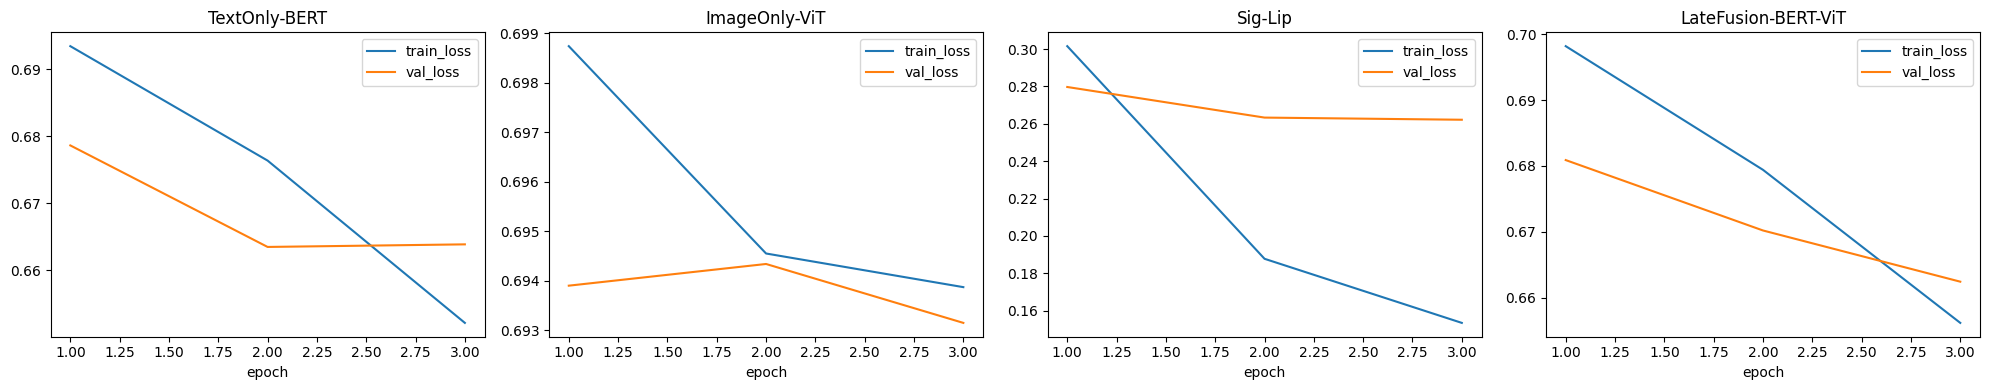

In [42]:
fig, axes = plt.subplots(1, max(1, len(results)), figsize=(5 * max(1, len(results)), 4))
if len(results) == 1:
    axes = [axes]

for ax, (name, pack) in zip(axes, results.items()):
    hist = pack["history"]
    ax.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    ax.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.legend()

plt.tight_layout()
plt.show()


In [43]:
for name, pack in results.items():
    print("=" * 100)
    print(name)
    print(pack["metrics"])
    print(classification_report(pack["y_true"], pack["y_pred"], digits=4))


TextOnly-BERT
{'acc': 0.5592, 'precision': 0.5362745098039216, 'recall': 0.8752, 'f1': 0.6650455927051672, 'roc_auc': 0.61302688, 'avg_precision': 0.5952588647649749, 'loss': 0.6824546170691712}
              precision    recall  f1-score   support

           0     0.6609    0.2432    0.3556      1250
           1     0.5363    0.8752    0.6650      1250

    accuracy                         0.5592      2500
   macro avg     0.5986    0.5592    0.5103      2500
weighted avg     0.5986    0.5592    0.5103      2500

ImageOnly-ViT
{'acc': 0.5, 'precision': 0.5, 'recall': 1.0, 'f1': 0.6666666666666666, 'roc_auc': 0.5, 'avg_precision': 0.5, 'loss': 0.6942782133532027}
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1250
           1     0.5000    1.0000    0.6667      1250

    accuracy                         0.5000      2500
   macro avg     0.2500    0.5000    0.3333      2500
weighted avg     0.2500    0.5000    0.3333      2500


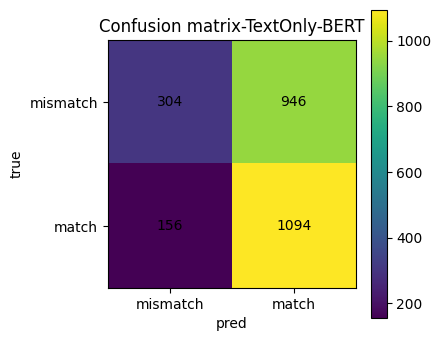

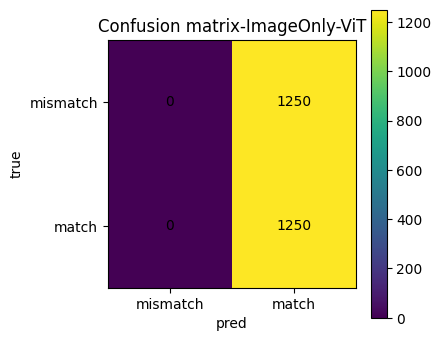

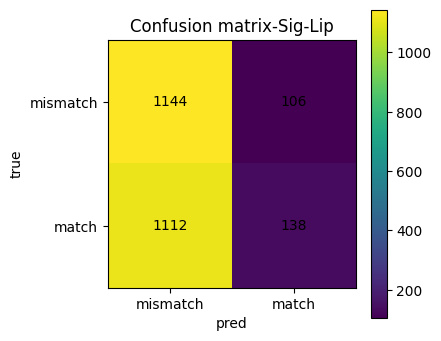

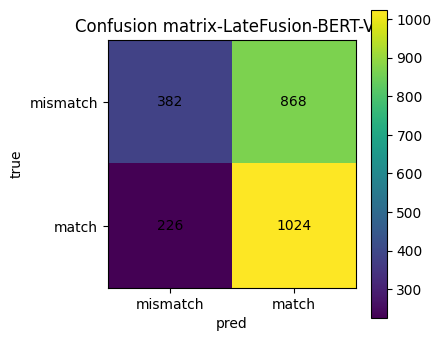

In [44]:
def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["mismatch", "match"])
    ax.set_yticklabels(["mismatch", "match"])
    ax.set_xlabel("pred")
    ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.colorbar(im, ax=ax)
    plt.show()

for name, pack in results.items():
    plot_confusion(pack["y_true"], pack["y_pred"], f"Confusion matrix-{name}")


#### **7. Análisis de ablaciones y preguntas relacionadas**

En esta sección se organizan los resultados en torno a tres preguntas de investigación que permiten interpretar de manera más precisa el comportamiento de las arquitecturas multimodales evaluadas. El objetivo no es solo identificar qué modelo obtiene el mejor resultado, sino aislar el efecto de decisiones concretas de diseño sobre el rendimiento final.

##### **A. ¿La fusión profunda supera a la fusión tardía?**

La primera comparación enfrenta:

* `LateFusion-BERT-ViT`
* `MMBT-ViT-grid-hard`

Esta ablación constituye el contraste central del cuaderno. Su propósito es evaluar si una arquitectura en la que imagen y texto interactúan **dentro del encoder**, mediante **self-attention** sobre una secuencia multimodal conjunta, ofrece una ventaja respecto de una estrategia en la que ambas modalidades solo se combinan al final. En términos conceptuales, esta comparación pone a prueba la hipótesis principal de que la **fusión profunda** puede capturar relaciones multimodales más expresivas que la **fusión tardía**.

#### **B. ¿Ayudan múltiples tokens visuales?**

La segunda comparación enfrenta:

* `MMBT-ViT-grid-hard`
* `MMBT-ViT-cls-hard`

Aquí el interés está en analizar el efecto de la **estructura de la representación visual**. Ambas variantes pertenecen a la misma familia arquitectónica, pero difieren en cómo la imagen entra al modelo: como **múltiples tokens visuales** en `grid`, o como un único token resumido en `cls`. Esta ablation permite examinar si representar la imagen como una secuencia más rica mejora la capacidad del modelo para interactuar con el texto dentro del encoder.

#### **C. ¿Los negativos semi-difíciles vuelven realmente más exigente la tarea?**

La tercera comparación enfrenta:

* `MMBT-ViT-grid-hard`
* `MMBT-ViT-grid-random`

Esta ablación se centra en la **dificultad del problema**. La arquitectura permanece fija, pero cambia la forma de construir los ejemplos negativos. Al comparar negativos **semi-difíciles** con negativos **aleatorios**, se puede estimar en qué medida el rendimiento depende de la capacidad real del modelo para discriminar alineamientos sutiles entre imagen y texto, y no simplemente de una tarea artificialmente sencilla.

En conjunto, estas tres ablaciones permiten estudiar de forma más rigurosa los tres ejes principales del cuaderno:

* la diferencia entre **fusión tardía** y **fusión profunda**,
* el papel de los **múltiples tokens visuales**,
* y el efecto de la **dificultad del dataset** sobre la interpretación de los resultados.

De este modo, la sección de ablaciones funciona como el núcleo analítico del cuaderno, ya que traduce los experimentos en preguntas metodológicas explícitas y comparables.


In [ ]:
def ablation_delta(df: pd.DataFrame, a: str, b: str, metric: str = "f1"):
    row_a = df.loc[df["model"] == a]
    row_b = df.loc[df["model"] == b]
    if len(row_a) == 0 or len(row_b) == 0:
        return None
    return float(row_a.iloc[0][metric] - row_b.iloc[0][metric])

comparisons = [
    ("MMBT-ViT-grid-hard", "LateFusion-BERT-ViT", "f1"),
    ("MMBT-ViT-grid-hard", "MMBT-ViT-cls-hard", "f1"),
    ("MMBT-ViT-grid-hard", "MMBT-ViT-grid-random", "f1"),
]

ablation_rows = []
for a, b, metric in comparisons:
    delta = ablation_delta(summary_df, a, b, metric=metric)
    if delta is not None:
        ablation_rows.append({
            "A": a,
            "B": b,
            "metric": metric,
            "A_minus_B": delta,
        })

pd.DataFrame(ablation_rows).sort_values("A_minus_B", ascending=False)


#### **8. Estratificación por dificultad y lectura cualitativa del rendimiento**

Una forma más fina de interpretar los resultados consiste en analizar cómo se comporta cada modelo según el nivel de dificultad de los ejemplos evaluados. En lugar de observar únicamente una métrica agregada, esta sección propone descomponer el rendimiento en subconjuntos que representan distintos grados de exigencia para la tarea multimodal.

En particular, se examina el comportamiento del modelo sobre cuatro tipos de casos:

* **positivos**,
* **negativos fáciles**,
* **negativos medios**,
* **negativos difíciles**.

Esta estratificación resulta metodológicamente útil porque permite distinguir entre mejoras aparentes y mejoras realmente informativas. Un modelo puede obtener buenos resultados globales si resuelve bien los ejemplos triviales, pero mostrar limitaciones en los casos donde la alineación entre imagen y texto es más ambigua o más sutil.

Desde la perspectiva central del cuaderno, esta sección permite evaluar con mayor precisión una hipótesis importante: si la **fusión profunda** aporta una ventaja real frente a la **fusión tardía**, esa diferencia debería manifestarse sobre todo en los ejemplos más difíciles, y no únicamente en los casos evidentes. Dicho de otro modo, el beneficio de una integración multimodal más profunda debería observarse con mayor claridad cuando el modelo necesita explotar interacciones finas entre tokens visuales y textuales para resolver la clasificación.

Por ello, la estratificación por dificultad no cumple solo una función descriptiva. También actúa como una herramienta analítica para examinar **dónde** aparece la ganancia del modelo y **qué tipo de dificultad** parece resolver mejor. En un contexto de nivel avanzado, esta lectura ayuda a pasar de una comparación puramente numérica a una interpretación más estructurada del comportamiento multimodal.


In [ ]:
def stratified_accuracy(eval_df: pd.DataFrame) -> pd.DataFrame:
    tmp = eval_df.copy()
    tmp["correct"] = (tmp["gold"] == tmp["pred"]).astype(int)
    out = tmp.groupby(["source", "difficulty"], dropna=False)["correct"].agg(["mean", "count"]).reset_index()
    out = out.rename(columns={"mean": "accuracy"})
    return out.sort_values(["source", "difficulty"])

strat_tables = {}
for name, pack in results.items():
    strat_tables[name] = stratified_accuracy(pack["eval_df"])
    print("\n", "=" * 100)
    print(name)
    display(strat_tables[name])


In [ ]:
# Comparación específica entre fusión tardía y MMBT sobre el subconjunto difícil
to_compare = [name for name in ["LateFusion-BERT-ViT", "MMBT-ViT-grid-hard"] if name in results]

if len(to_compare) == 2:
    merged = []
    for name in to_compare:
        tmp = results[name]["eval_df"].copy()
        tmp["correct"] = (tmp["gold"] == tmp["pred"]).astype(int)
        tmp = tmp.groupby("difficulty")["correct"].mean().reset_index()
        tmp["model"] = name
        merged.append(tmp)
    merged = pd.concat(merged, ignore_index=True)

    pivot = merged.pivot(index="difficulty", columns="model", values="correct")
    pivot


#### **9. Análisis de errores y límites del modelo**

Esta sección incorpora un análisis de errores orientado a examinar **dónde** falla el mejor modelo y **qué tipo de dificultad** permanece sin resolverse, incluso cuando el rendimiento agregado es alto.

La estrategia consiste en recuperar los errores más confiados del modelo, es decir, aquellos casos en los que la predicción fue incorrecta a pesar de haberse realizado con alta seguridad. Este tipo de ejemplos resulta especialmente informativo porque permite identificar no solo fallos aislados, sino también patrones sistemáticos en la forma en que el modelo integra o deja de integrar la información multimodal.

En particular, el análisis presta atención a varios tipos de errores relevantes:

* **captions muy genéricos**, que pueden ser compatibles con una gran variedad de imágenes y dificultan la discriminación fina,
* **escenas visualmente parecidas**, donde la similitud entre imágenes vuelve más ambigua la decisión,
* **fallos asociados a sesgos del lenguaje**, en los que el modelo parece apoyarse excesivamente en pistas textuales frecuentes,
* y **negativos demasiado plausibles**, que exigen una alineación multimodal más precisa para ser descartados correctamente.

Desde una perspectiva metodológica, esta sección permite complementar la evaluación cuantitativa con una lectura más interpretativa del comportamiento del modelo. En lugar de preguntar solo cuánto acierta, interesa entender **por qué se equivoca**, **qué regularidades está explotando** y **qué límites muestra cuando la correspondencia entre imagen y texto deja de ser evidente**.

De este modo, el análisis de errores funciona como una extensión natural de las ablaciones y de la estratificación por dificultad: ayuda a conectar los resultados numéricos con fenómenos concretos del dataset y ofrece una base más sólida para discutir fortalezas, debilidades y posibles mejoras de la arquitectura multimodal.


In [ ]:
best_model_name = summary_df.iloc[0]["model"]
best_eval_df = results[best_model_name]["eval_df"].copy()

best_eval_df["error"] = (best_eval_df["gold"] != best_eval_df["pred"]).astype(int)
best_eval_df["confidence"] = np.where(
    best_eval_df["pred"] == 1,
    best_eval_df["prob_match"],
    1.0 - best_eval_df["prob_match"],
)

worst_errors = (
    best_eval_df.loc[best_eval_df["error"] == 1]
    .sort_values("confidence", ascending=False)
    .head(12)
    .reset_index(drop=True)
)

worst_errors[["hf_index", "image_id", "gold", "pred", "prob_match", "source", "difficulty", "caption_len", "caption"]]


In [ ]:
def show_error_examples(dataset, error_df: pd.DataFrame, n: int = 4):
    subset = error_df.head(n)
    fig, axes = plt.subplots(len(subset), 2, figsize=(12, 4 * len(subset)))
    if len(subset) == 1:
        axes = np.array([axes])

    for row_idx, (_, row) in enumerate(subset.iterrows()):
        ex = dataset.hf_split[int(row["hf_index"])]
        axes[row_idx, 0].imshow(ex["image"])
        axes[row_idx, 0].axis("off")
        axes[row_idx, 0].set_title(f'image_id={row["image_id"]} | gold={row["gold"]} | pred={row["pred"]}')

        axes[row_idx, 1].axis("off")
        txt = (
            f'caption: {row["caption"]}\n\n'
            f'source: {row["source"]} | difficulty: {row["difficulty"]}\n'
            f'prob_match: {row["prob_match"]:.4f}'
        )
        axes[row_idx, 1].text(0, 0.9, txt, wrap=True, fontsize=11)

    plt.tight_layout()
    plt.show()

dataset_for_best = test_ds_hard if results[best_model_name]["variant"] == "hard" else None
if dataset_for_best is not None:
    show_error_examples(dataset_for_best, worst_errors, n=min(4, len(worst_errors)))


#### **10. Visualización opcional de atención multimodal**

Esta celda por que sirve para mostrar que en MMBT la decisión no depende solo de un vector final concatenado, sino de una interacción interna entre el token `[CLS]` y los tokens visuales.


In [ ]:
def show_mmbt_attention_example(model, ds, sample_idx: int = 0, device=None):
    device = DEVICE if device is None else torch.device(device)
    model.eval()

    item = ds[sample_idx]
    batch = collate_fn([item])

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    pixel_values = batch["pixel_values"].to(device)

    with torch.no_grad():
        out = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            output_attentions=True,
        )

    probs = out["logits"].softmax(dim=-1)[0].cpu().numpy()
    pred = int(probs.argmax())
    text_len = input_ids.shape[1]
    num_visual = int(out["num_visual_tokens"])

    last_att = out["attentions"][-1][0]       # [heads, seq, seq]
    cls_to_all = last_att[:, 0, :].mean(dim=0).cpu().numpy()
    cls_to_visual = cls_to_all[text_len:text_len + num_visual]

    if num_visual > 1:
        gh, gw = model.visual_grid
        if gh * gw == num_visual:
            cls_to_visual = cls_to_visual.reshape(gh, gw)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(item["image"])
    axes[0].axis("off")
    axes[0].set_title("Imagen")

    axes[1].axis("off")
    axes[1].text(0, 0.7, item["caption"], wrap=True, fontsize=12)
    axes[1].set_title(f'Caption | true={item["label"]} | pred={pred}')

    if isinstance(cls_to_visual, np.ndarray) and cls_to_visual.ndim == 2:
        heat = axes[2].imshow(cls_to_visual)
        axes[2].set_xticks(range(cls_to_visual.shape[1]))
        axes[2].set_yticks(range(cls_to_visual.shape[0]))
        axes[2].set_title("CLS -> tokens visuales")
        plt.colorbar(heat, ax=axes[2])
    else:
        axes[2].bar(range(len(np.ravel(cls_to_visual))), np.ravel(cls_to_visual))
        axes[2].set_title("CLS -> token(s) visual(es)")

    plt.tight_layout()
    plt.show()

mmbt_name = "MMBT-ViT-grid-hard" if "MMBT-ViT-grid-hard" in results else None
if CONFIG["show_attention_example"] and mmbt_name is not None:
    show_mmbt_attention_example(results[mmbt_name]["model"], test_ds_hard, sample_idx=3)


#### **11. Preguntas para profundización, seminario o trabajo final**


**1. ¿Cómo cambia el rendimiento del sistema al modificar el encoder visual?**
Compara el modelo actual con alternativas de distinta capacidad, por ejemplo `google/vit-base-patch16-224`, `google/vit-large-patch16-224` o `facebook/convnext-tiny-224`. Analiza el efecto sobre desempeño, costo computacional y estabilidad de entrenamiento.

**2. ¿Qué estrategia de fine-tuning favorece una mejor integración multimodal?**
Evalua distintas variantes de entrenamiento, como congelar temporalmente el encoder textual, congelar el encoder visual o ajustar todo el sistema de extremo a extremo desde el inicio. Discute cómo estas decisiones afectan la convergencia y la calidad de la fusión.

**3. ¿Qué ocurre si los negativos se construyen con embeddings semánticos en lugar de TF-IDF?**
Reemplaza el método actual de selección de negativos por alternativas como **SBERT** o **CLIP text embeddings**. Analiza si esto vuelve la tarea más exigente y si permite distinguir con mayor claridad entre fusión tardía y fusión profunda.

**4. ¿Qué información adicional aportan métricas más allá de accuracy y F1?**

**5. ¿Se mantienen las conclusiones del cuaderno al cambiar de dataset?**
Repite el protocolo en otro conjunto de datos real, como **Food101** con texto asociado, un subconjunto de **MM-IMDB** o un benchmark pequeño de **entailment multimodal**, y compara si las ventajas observadas para fusión profunda se sostienen en otro dominio.

**6. ¿Qué modificaciones requiere el sistema para pasar de clasificación binaria a tareas más complejas?**
Explora cómo adaptar la arquitectura y el protocolo experimental a problemas como **retrieval bidireccional**, **reranking** o **entailment multimodal**, indicando qué cambia en la formulación, la pérdida y la evaluación.

**7. ¿En qué tipo de ejemplos aparece realmente la ventaja de la fusión profunda?**
Analiza si las diferencias frente a la fusión tardía se concentran en ejemplos difíciles, negativos plausibles o casos donde la alineación imagen-texto es más sutil.

**8. ¿Hasta qué punto la mejora del modelo depende de la arquitectura y no de la dificultad del dataset?**
Compara variantes con negativos aleatorios, medios y semi-difíciles para discutir cuánto del rendimiento proviene de la capacidad multimodal del sistema y cuánto de la construcción del problema.
